In [1]:
#This dataset is a version of original Credit Risk dataset on Kaggle 
#and had additional variables added to this version of the Credit Risk dataset based on Financial Risk for Loan Approval data
#These values are based off of categorical, ordinal, and continuous variables

import pandas as pd
import numpy as np
!pip install xgboost
df = pd.read_csv("Classification.csv")


print(df.head())
print(df.info())
print(df.isnull().sum())

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

Lo, T. (2024). Loan Approval Classification Dataset. Kaggle.com. https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

‌

In [2]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

#Select target variable (loan_status)
#Separate features from the target variable
#Encode categorical features using one-hot encoding
#drop_first avoids multicollinearity
#Split data into training and testing sets
#80% training and 20% testing
#Stratify maintains class balance
#Display training data shape to verify split

y = df["loan_status"]
X = df.drop("loan_status", axis=1)


X_encoded = pd.get_dummies(X, columns=X.select_dtypes(include=['object']).columns, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape:", X_train.shape)

Shape: (36000, 22)


scikit-learn. (2018). sklearn.model_selection.train_test_split — scikit-learn 0.20.3 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

‌

In [3]:
#Logistic Regression

#GridSearchCV tests different parameter combinations
#cv=5 uses 5-fold cross-validation for model evaluation
#Scoring metric: ROC-AUC

#Hyperparameters:
#C: regularization strength (smaller = stronger regularization)
#penalty: L2 regularization to prevent overfitting
#solver: optimization algorithm compatible with L2 penalty

#GridSearchCV selects the best Logistic Regression model based on ROC-AUC performance

lr_param = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"]
}
lr = LogisticRegression(random_state=42, max_iter=1000)
lr_cv = GridSearchCV(lr, lr_param, cv=5, scoring="roc_auc")
lr_cv.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['liblinear']},
             scoring='roc_auc')

scikit-learn. (2014). LogisticRegression. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

‌

In [4]:
#Random Forest

#GridSearchCV tests different parameter combinations
#cv=5 uses 5-fold cross-validation for model evaluation
#Scoring metric: ROC-AUC

#Hyperparameters:
#n_estimators: number of decision trees in the forest (fixed at 100)
#max_depth: maximum depth of each tree (tested at 5 and 10 to control overfitting)
#class_weight: set to "balanced" to automatically adjust weights inversely proportional to class frequencies

#GridSearchCV selects the best Random Forest model based on ROC-AUC performance

rf_param = {
    "n_estimators": [100],
    "max_depth": [5, 10],
    "class_weight": ["balanced"]
}
rfc = RandomForestClassifier(random_state=42)
rfc_cv = GridSearchCV(rfc, rf_param, cv=5, scoring="roc_auc")
rfc_cv.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': ['balanced'], 'max_depth': [5, 10],
                         'n_estimators': [100]},
             scoring='roc_auc')

scikit-learn. (2024). RandomForestClassifier. Scikit-Learn.org. https://scikit-learn.org/1.6/modules/generated/sklearn.ensemble.RandomForestClassifier.html.

In [5]:
#XGBoost Classifier

#Gradient boosting model that builds trees sequentially
#Each tree focuses on correcting previous prediction errors
#GridSearchCV used to tune model hyperparameters
#cv=5 applies 5-fold cross-validation
#Scoring metric: ROC-AUC

#Hyperparameters:
#max_depth: controls tree complexity
#learning_rate: controls how much each tree contributes
#n_estimators: number of boosting trees
#gamma: minimum loss reduction needed to split a node


#GridSearchCV selects the best Random XGBoost based on ROC-AUC performance

xgb_param = {
    "max_depth": [3, 5],
    "learning_rate": [0.1],
    "n_estimators": [100],
    "gamma": [0]
}
xgb = XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False)
xgb_cv = GridSearchCV(xgb, xgb_param, cv=5, scoring="roc_auc")
xgb_cv.fit(X_train, y_train)


C:\Users\slapm\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:31:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\slapm\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:31:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\slapm\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:31:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\slapm\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:31:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'gamma': [0], 'learning_rate': [0.1],
                         'max_depth': [3, 5], 'n_estimators': [100]},
             scoring='roc_auc')

Python API Reference — xgboost 1.7.5 documentation. (n.d.). Xgboost.readthedocs.io. https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier

‌


Logistic Regression
→ AUC: 0.780, Accuracy: 0.794
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      7000
           1       0.72      0.12      0.21      2000

    accuracy                           0.79      9000
   macro avg       0.76      0.55      0.55      9000
weighted avg       0.78      0.79      0.73      9000



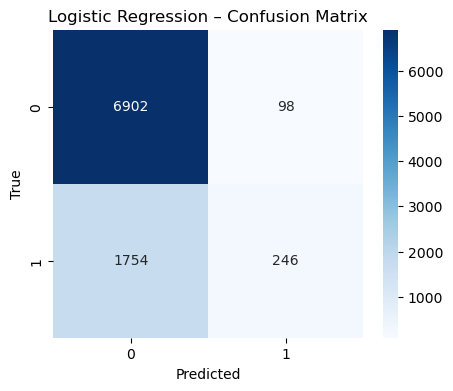


Random Forest
→ AUC: 0.971, Accuracy: 0.895
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      7000
           1       0.71      0.90      0.79      2000

    accuracy                           0.89      9000
   macro avg       0.84      0.90      0.86      9000
weighted avg       0.91      0.89      0.90      9000



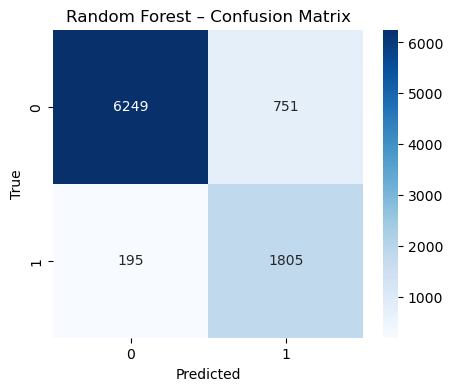


XGBoost
→ AUC: 0.975, Accuracy: 0.929
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7000
           1       0.89      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



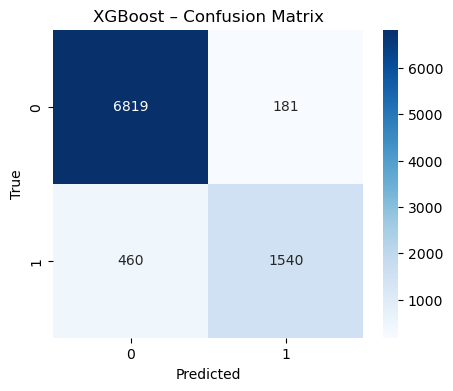


 Summary Table:
                 Model       AUC  Accuracy
0  Logistic Regression  0.780286  0.794222
1        Random Forest  0.971383  0.894889
2              XGBoost  0.975499  0.928778


In [6]:
#Model evaluation and comparison
#Evaluate_classification evaluates trained classification models on test data

#Generates predictions from the model
#Prints performance results for easy interpretation
#Visualizes results using a confusion matrix

#This evaluation helps determine which model performs best on unseen data and supports model selection
# Trained classification models (Logistic Regresion, Random Forest, XGBoost)
# X_test: features for testing
# y_test: true target values for testing


def evaluate_classification(name, model, X_test, y_test):
    pred = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, pred_proba)
    acc = accuracy_score(y_test, pred)
    print(f"\n{name}")
    print(f"→ AUC: {auc:.3f}, Accuracy: {acc:.3f}")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} – Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.show()

    return {"Model": name, "AUC": auc, "Accuracy": acc}


eval_results = []
eval_results.append(evaluate_classification("Logistic Regression", lr_cv.best_estimator_, X_test, y_test))
eval_results.append(evaluate_classification("Random Forest", rfc_cv.best_estimator_, X_test, y_test))
eval_results.append(evaluate_classification("XGBoost", xgb_cv.best_estimator_, X_test, y_test))


results_df = pd.DataFrame(eval_results)
print("\n Summary Table:")
print(results_df)

scikit-learn. (2019). sklearn.metrics.confusion_matrix — scikit-learn 0.21.3 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

‌